# 🎬 Netflix Multi-Table Analysis

**Analyst:** _(your name)_

**Goal:** Explore Netflix's catalog, ratings, and viewership across 5 related tables to deliver strategic content recommendations.

## 1. Setup — Load All 5 Tables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

titles     = pd.read_csv("titles.csv")
genres     = pd.read_csv("genres.csv")
cast       = pd.read_csv("cast.csv")
ratings    = pd.read_csv("ratings.csv")
viewership = pd.read_csv("viewership.csv")

print("titles    :", titles.shape)
print("genres    :", genres.shape)
print("cast      :", cast.shape)
print("ratings   :", ratings.shape)
print("viewership:", viewership.shape)

titles    : (802, 9)
genres    : (1591, 3)
cast      : (3196, 4)
ratings   : (33535, 5)
viewership: (48643, 4)


## 2. Explore Each Table Separately
Understand each table's grain, dtypes, and missing values **before** merging anything.

## 3. Data Cleaning
- Handle duplicates and missing values
- Convert date columns to datetime
- Extract numeric duration from `titles`
- Any other cleaning you find necessary

### Titles

In [2]:
# Your exploration code here (titles)
# Your cleaning code here
titles  # Just look at the table

,title_id,type,title,director,country,date_added,release_year,content_rating,duration
0,t0001,Movie,Above War,Guillermo del Toro,Nigeria,2021-04-11,2018,PG,179 min
1,t0002,Movie,Modern Dream,David Fincher,Canada,2016-01-07,2021,TV-MA,138 min
2,t0003,Movie,The Life Season,Céline Sciamma,Nigeria,2017-09-17,2010,NaN,146 min
3,t0004,Movie,Under Days,Wes Anderson,Nigeria,2022-05-06,1997,PG-13,105 min
4,t0005,Movie,Lost Kingdom,NaN,India,2018-04-06,2023,TV-14,119 min
...,...,...,...,...,...,...,...,...,...
797,t0798,TV Show,Ancient Sun: Reborn,NaN,United States,2017-09-24,2010,TV-MA,8 Seasons
798,t0799,Movie,Golden Water: Origins,NaN,Japan,2022-12-05,2002,TV-PG,83 min
799,t0800,Movie,Wild Chronicle Files,Bong Joon-ho,Germany,2022-04-21,2019,NR,87 min
800,t0016,TV Show,Lost House Season,Sofia Coppola,United States,2018-10-31,2018,PG-13,6 Seasons


In [3]:
titles.dtypes  # types of columns - only numeric one is release_year; gotta change the date_added to dates

title_id            str
type                str
title               str
director            str
country             str
date_added          str
release_year      int64
content_rating      str
duration            str
dtype: object

In [4]:
titles['date_added'] = pd.to_datetime(titles['date_added'])

In [5]:
titles.info()  # info - many columns have empty cells

<class 'pandas.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title_id        802 non-null    str           
 1   type            802 non-null    str           
 2   title           802 non-null    str           
 3   director        612 non-null    str           
 4   country         737 non-null    str           
 5   date_added      773 non-null    datetime64[us]
 6   release_year    802 non-null    int64         
 7   content_rating  781 non-null    str           
 8   duration        802 non-null    str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 56.5 KB


In [6]:
titles.duplicated().sum()  # there are duplicates - remove them

np.int64(2)

In [7]:
titles[titles.duplicated()]

,title_id,type,title,director,country,date_added,release_year,content_rating,duration
800,t0016,TV Show,Lost House Season,Sofia Coppola,United States,2018-10-31,2018,PG-13,6 Seasons
801,t0143,Movie,Forgotten Dream,Kathryn Bigelow,China,2021-09-26,1995,R,139 min


As we see, last two rows are duplicates, with title_ids 16 and 143. This is important, as we come across them later.

In [8]:
titles = titles.drop_duplicates()
titles

,title_id,type,title,director,country,date_added,release_year,content_rating,duration
0,t0001,Movie,Above War,Guillermo del Toro,Nigeria,2021-04-11,2018,PG,179 min
1,t0002,Movie,Modern Dream,David Fincher,Canada,2016-01-07,2021,TV-MA,138 min
2,t0003,Movie,The Life Season,Céline Sciamma,Nigeria,2017-09-17,2010,NaN,146 min
3,t0004,Movie,Under Days,Wes Anderson,Nigeria,2022-05-06,1997,PG-13,105 min
4,t0005,Movie,Lost Kingdom,NaN,India,2018-04-06,2023,TV-14,119 min
...,...,...,...,...,...,...,...,...,...
795,t0796,TV Show,Eternal House,Céline Sciamma,Japan,2021-10-07,1995,G,6 Seasons
796,t0797,TV Show,Beyond Secret: Reborn,Guillermo del Toro,Japan,NaT,2014,PG-13,9 Seasons
797,t0798,TV Show,Ancient Sun: Reborn,NaN,United States,2017-09-24,2010,TV-MA,8 Seasons
798,t0799,Movie,Golden Water: Origins,NaN,Japan,2022-12-05,2002,TV-PG,83 min


In [9]:
titles['title_id'].value_counts().max()  # check that ids are unique

np.int64(1)

In [10]:
titles['type'].value_counts()  # see the distribution of movie vs tv show

type
Movie      527
TV Show    273
Name: count, dtype: int64

In [11]:
titles['title'].value_counts()  # some titles are the same, which is entirely possible

title
Above Day                5
Above Shadow             4
Dark Star                3
The Journey              3
Forgotten Shadow         3
                        ..
Eternal House            1
Beyond Secret: Reborn    1
Ancient Sun: Reborn      1
Golden Water: Origins    1
Wild Chronicle Files     1
Name: count, Length: 693, dtype: int64

In [12]:
titles['director'].fillna('UNKNOWN').value_counts()  # about 1/4 of directors are unknown

director
UNKNOWN               190
Martin Scorsese        44
Barry Jenkins          43
Kathryn Bigelow        41
Céline Sciamma         38
Sofia Coppola          38
Chloe Zhao             35
Hayao Miyazaki         35
Ava DuVernay           30
Jane Campion           30
Ridley Scott           30
David Fincher          27
Greta Gerwig           26
Bong Joon-ho           26
Zhang Yimou            26
Anurag Kashyap         25
Pedro Almodóvar        25
Christopher Nolan      25
Denis Villeneuve       24
Wes Anderson           23
Guillermo del Toro     19
Name: count, dtype: int64

In [13]:
titles['country'].fillna('UNKNOWN').value_counts()  # about 8% of countries are unknown

country
UNKNOWN           65
Australia         58
Nigeria           50
Japan             49
Mexico            49
India             45
United Kingdom    45
France            43
Turkey            43
China             43
South Korea       41
Italy             41
Germany           40
Spain             39
United States     39
Canada            37
Brazil            37
Egypt             36
Name: count, dtype: int64

In [14]:
titles['date_added'].dropna().sort_values()  # 29/800 date_added-s are NaT, otherwise the dates are between 2015 to 2023

731   2015-01-03
556   2015-01-25
365   2015-01-28
728   2015-02-06
54    2015-02-08
         ...    
75    2023-12-19
32    2023-12-23
208   2023-12-27
514   2023-12-28
747   2023-12-29
Name: date_added, Length: 771, dtype: datetime64[us]

In [ ]:
titles['date_added'].dropna().sort_values()

731   2015-01-03
556   2015-01-25
365   2015-01-28
728   2015-02-06
54    2015-02-08
         ...    
75    2023-12-19
32    2023-12-23
208   2023-12-27
514   2023-12-28
747   2023-12-29
Name: date_added, Length: 771, dtype: datetime64[us]

Our service started working at the beginning of 2015, so we need to keep that in mind for later.

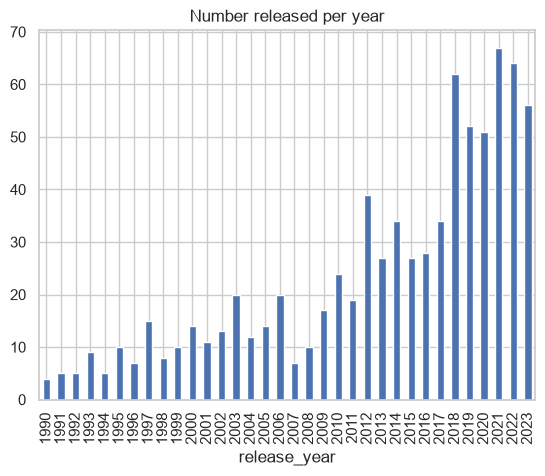

In [15]:
titles['release_year'].value_counts().sort_index().plot(kind='bar')
plt.title('Number released per year')
plt.show()

We see that the number of movies/shows released grows fast with years.

In [16]:
titles['content_rating'].fillna('UNKNOWN').value_counts()  # 1/40 of movies have no content rating, otherwise there are only 10 categories here

content_rating
TV-PG      91
TV-Y       88
TV-Y7      84
R          84
PG         81
TV-14      81
NR         72
PG-13      70
G          67
TV-MA      61
UNKNOWN    21
Name: count, dtype: int64

In [17]:
titles[['duration_num', 'duration_unit']] = titles['duration'].str.split(' ', expand=True)
titles['duration_num'] = titles['duration_num'].astype(int)
titles

,title_id,type,title,director,country,date_added,release_year,content_rating,duration,duration_num,duration_unit
0,t0001,Movie,Above War,Guillermo del Toro,Nigeria,2021-04-11,2018,PG,179 min,179,min
1,t0002,Movie,Modern Dream,David Fincher,Canada,2016-01-07,2021,TV-MA,138 min,138,min
2,t0003,Movie,The Life Season,Céline Sciamma,Nigeria,2017-09-17,2010,NaN,146 min,146,min
3,t0004,Movie,Under Days,Wes Anderson,Nigeria,2022-05-06,1997,PG-13,105 min,105,min
4,t0005,Movie,Lost Kingdom,NaN,India,2018-04-06,2023,TV-14,119 min,119,min
...,...,...,...,...,...,...,...,...,...,...,...
795,t0796,TV Show,Eternal House,Céline Sciamma,Japan,2021-10-07,1995,G,6 Seasons,6,Seasons
796,t0797,TV Show,Beyond Secret: Reborn,Guillermo del Toro,Japan,NaT,2014,PG-13,9 Seasons,9,Seasons
797,t0798,TV Show,Ancient Sun: Reborn,NaN,United States,2017-09-24,2010,TV-MA,8 Seasons,8,Seasons
798,t0799,Movie,Golden Water: Origins,NaN,Japan,2022-12-05,2002,TV-PG,83 min,83,min


Check the duration distributions for movies and shows:

In [18]:
titles[titles['type'] == 'Movie']['duration_unit'].value_counts()  # check that all movies have minutes as their duration

duration_unit
min    527
Name: count, dtype: int64

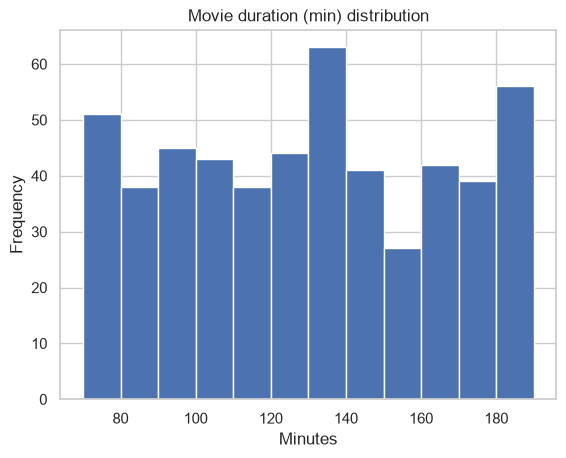

In [19]:
titles[titles['type'] == 'Movie']['duration_num'].plot(kind='hist', bins=12)
plt.xlabel('Minutes')
plt.title('Movie duration (min) distribution')
plt.show()

Movie duration is vaguely uniformly distributed between about 70 minutes to just over 3 hours.

In [20]:
titles[titles['type'] == 'TV Show']['duration_unit'].value_counts()  # check that all tv shows have seasons as their duration

duration_unit
Seasons    273
Name: count, dtype: int64

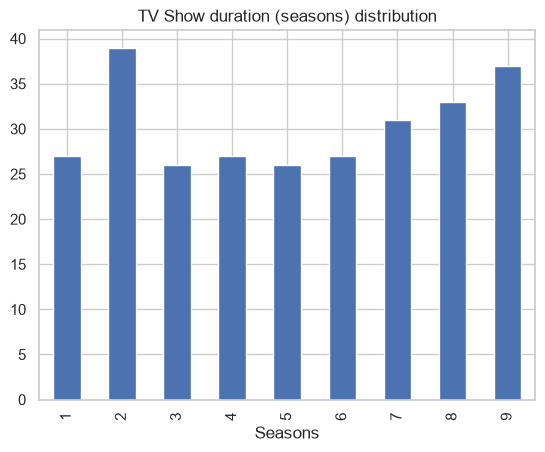

In [21]:
titles[titles['type'] == 'TV Show']['duration_num'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Seasons')
plt.title('TV Show duration (seasons) distribution')
plt.show()

Show length distribution has a peak at 2 seasons and also grows towards up to 9 seasons.

In all three string columns with NaNs we can just input Unknown. With dates it is less clear, but considering there is only about 30 of missing date_added entries, we can input (release-year)-06-30 as a heuristic - the middle point of the release year for that movie. It won't skew the stats much and it makes sense as an approximation. We also have to be careful with older movies - of course there are movies released way before our service started working - for those we just impute the date_added with the January 1st 2015. It makes sense here since it is normal to assume that when we start our service, we add a bunch of well-known older movies to the database right away.

In [25]:
titles['director'] = titles['director'].fillna('Unknown')
titles['country'] = titles['country'].fillna('Unknown')
titles['content_rating'] = titles['content_rating'].fillna('Unknown')
titles['date_added'] = titles['date_added'].fillna(
    np.maximum(
        pd.to_datetime('2015-01-01'),
        pd.to_datetime(titles['release_year'].astype(str) + '-06-30')
    )
)
titles.isna().sum()

title_id          0
type              0
title             0
director          0
country           0
date_added        0
release_year      0
content_rating    0
duration          0
duration_num      0
duration_unit     0
dtype: int64

### Genres

In [26]:
# genres
genres

,genre_id,title_id,genre
0,1,t0001,Kids' TV
1,2,t0002,Horror Movies
2,3,t0002,Music & Musicals
3,4,t0003,Sci-Fi & Fantasy
4,5,t0003,Romantic Movies
...,...,...,...
1586,1587,t0800,Anime
1587,1588,t0016,Anime
1588,1589,t0016,Thrillers
1589,1590,t0143,Documentaries


In [27]:
genres.tail(10)

,genre_id,title_id,genre
1581,1582,t0798,Sci-Fi & Fantasy
1582,1583,t0799,International
1583,1584,t0799,Reality TV
1584,1585,t0800,Documentaries
1585,1586,t0800,Reality TV
1586,1587,t0800,Anime
1587,1588,t0016,Anime
1588,1589,t0016,Thrillers
1589,1590,t0143,Documentaries
1590,1591,t0143,Classic


In [28]:
genres.dtypes

genre_id    int64
title_id      str
genre         str
dtype: object

In [29]:
genres.info()  # no NaNs in this table

<class 'pandas.DataFrame'>
RangeIndex: 1591 entries, 0 to 1590
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   genre_id  1591 non-null   int64
 1   title_id  1591 non-null   str  
 2   genre     1591 non-null   str  
dtypes: int64(1), str(2)
memory usage: 37.4 KB


In [30]:
genres.duplicated().any(), genres.duplicated(['title_id', 'genre']).any()  # no duplicates, checking also by title+genre

(np.False_, np.False_)

In [31]:
genres['genre_id'].value_counts().max()  # check that genre_id is unique

np.int64(1)

In [32]:
set(genres['title_id']) == set(titles['title_id'])  # each movie has at least genre

True

In [33]:
genres['title_id'].value_counts().value_counts()  # each movie has up to 3 genres except one, let's look at it

count
1    277
3    265
2    257
5      1
Name: count, dtype: int64

In [34]:
genres[genres['title_id'] == genres['title_id'].value_counts().idxmax()] 

,genre_id,title_id,genre
31,32,t0016,Documentaries
32,33,t0016,Horror Movies
33,34,t0016,Comedies
1587,1588,t0016,Anime
1588,1589,t0016,Thrillers


Note that this is title_id 16. Also, 16 and 143 are added to the end of this table as well. Lets see if they are present in the center of the table:

In [35]:
genres.index[genres['title_id'] == 't0016']

Index([31, 32, 33, 1587, 1588], dtype='int64')

In [36]:
genres.index[genres['title_id'] == 't0143']

Index([272, 1589, 1590], dtype='int64')

So yes - last 4 rows of the table are most certainly duplicates, even if they are not strictly speaking the exact duplicates of other rows in the table. We need to remove them too.

In [37]:
genres = genres[~((genres.index > 1000) & (genres['title_id'].isin(['t0016', 't0143'])))]
genres

,genre_id,title_id,genre
0,1,t0001,Kids' TV
1,2,t0002,Horror Movies
2,3,t0002,Music & Musicals
3,4,t0003,Sci-Fi & Fantasy
4,5,t0003,Romantic Movies
...,...,...,...
1582,1583,t0799,International
1583,1584,t0799,Reality TV
1584,1585,t0800,Documentaries
1585,1586,t0800,Reality TV


In [ ]:
genres['title_id'].value_counts().value_counts()  # now each movie only has up to 3 genres

count
1    278
3    265
2    257
Name: count, dtype: int64

In [38]:
genres['genre'].value_counts()

genre
Comedies              105
Documentaries         102
Stand-Up Comedy        96
Romantic Movies        90
Independent            86
LGBTQ                  86
Thrillers              86
Reality TV             85
Crime                  83
Kids' TV               81
Anime                  81
Sci-Fi & Fantasy       80
Dramas                 79
Horror Movies          78
Music & Musicals       78
Sports                 77
Classic                75
Action & Adventure     70
International          69
Name: count, dtype: int64

### Cast

In [39]:
# cast
cast

,cast_id,title_id,actor_name,role_type
0,1,t0001,Ken Watanabe,Supporting
1,2,t0001,Tom Hanks,Lead
2,3,t0002,Adam Driver,Lead
3,4,t0002,Mahershala Ali,Supporting
4,5,t0002,Florence Pugh,Supporting
...,...,...,...,...
3191,3192,t0143,Denzel Washington,Supporting
3192,3193,t0143,Cate Blanchett,Supporting
3193,3194,t0143,Oscar Isaac,Supporting
3194,3195,t0143,Timothée Chalamet,Supporting


In [40]:
cast.dtypes

cast_id       int64
title_id        str
actor_name      str
role_type       str
dtype: object

In [41]:
cast.info()  # 5 empty actor_names - fill them with Unknown

<class 'pandas.DataFrame'>
RangeIndex: 3196 entries, 0 to 3195
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   cast_id     3196 non-null   int64
 1   title_id    3196 non-null   str  
 2   actor_name  3191 non-null   str  
 3   role_type   3196 non-null   str  
dtypes: int64(1), str(3)
memory usage: 100.0 KB


In [42]:
cast['actor_name'] = cast['actor_name'].fillna('Unknown')
cast.isna().sum()

cast_id       0
title_id      0
actor_name    0
role_type     0
dtype: int64

In [43]:
cast.duplicated().any(), cast.duplicated(['title_id', 'actor_name']).any()  # there are repeat cast in some titles

(np.False_, np.True_)

In [44]:
repeated_cast = cast.fillna('Unknown').groupby(['title_id', 'actor_name']).size().sort_values()
cast.set_index(['title_id', 'actor_name']).loc[repeated_cast.index[repeated_cast >= 2]]

cast_id   role_type
title_id actor_name                            
t0016    Javier Bardem           61  Supporting
         Javier Bardem         3189  Supporting
         Song Kang-ho            63  Supporting
         Song Kang-ho          3187        Lead
         Tom Hanks               62  Supporting
         Tom Hanks             3190        Lead
t0143    Timothée Chalamet      553  Supporting
         Timothée Chalamet     3195  Supporting

In [45]:
cast.tail(15)

,cast_id,title_id,actor_name,role_type
3181,3182,t0800,Awkwafina,Supporting
3182,3183,t0800,Regé-Jean Page,Lead
3183,3184,t0800,Tessa Thompson,Supporting
3184,3185,t0800,Penélope Cruz,Supporting
3185,3186,t0016,Gong Yoo,Lead
3186,3187,t0016,Song Kang-ho,Lead
3187,3188,t0016,Denzel Washington,Lead
3188,3189,t0016,Javier Bardem,Supporting
3189,3190,t0016,Tom Hanks,Lead
3190,3191,t0143,Tom Hanks,Lead


In [46]:
cast.index[cast['title_id'] == 't0016']

Index([60, 61, 62, 63, 64, 3185, 3186, 3187, 3188, 3189], dtype='int64')

In [47]:
cast.index[cast['title_id'] == 't0143']

Index([552, 553, 3190, 3191, 3192, 3193, 3194, 3195], dtype='int64')

Once again we see those two problematic entries.

In [48]:
cast = cast[~((cast.index > 3000) & (cast['title_id'].isin(['t0016', 't0143'])))]
cast

,cast_id,title_id,actor_name,role_type
0,1,t0001,Ken Watanabe,Supporting
1,2,t0001,Tom Hanks,Lead
2,3,t0002,Adam Driver,Lead
3,4,t0002,Mahershala Ali,Supporting
4,5,t0002,Florence Pugh,Supporting
...,...,...,...,...
3180,3181,t0800,Adam Driver,Supporting
3181,3182,t0800,Awkwafina,Supporting
3182,3183,t0800,Regé-Jean Page,Lead
3183,3184,t0800,Tessa Thompson,Supporting


In [49]:
cast.duplicated().any(), cast.duplicated(['title_id', 'actor_name']).any()

(np.False_, np.False_)

In [50]:
cast['cast_id'].value_counts().max()  # check that ids are unique

np.int64(1)

In [51]:
cast['title_id'].value_counts().value_counts()  # the distribution of number of actors per film is very uniform and has no films with just 1 actor

count
4    167
3    167
5    160
2    155
6    151
Name: count, dtype: int64

In [52]:
set(cast['title_id']) == set(titles['title_id'])  # each movie has cast

True

In [53]:
cast['actor_name'].value_counts()
# each actor has over 50 occurences in different titles, except the Unknown ones
# there are just 5 rows with unknown actors

actor_name
Penélope Cruz          108
Ken Watanabe            94
Anya Taylor-Joy         94
Saoirse Ronan           90
Adam Driver             89
Song Kang-ho            88
Awkwafina               88
Deepika Padukone        88
Idris Elba              87
Viola Davis             87
Oscar Isaac             85
Lee Jung-jae            85
Millie Bobby Brown      84
Meryl Streep            84
Marion Cotillard        83
Rami Malek              83
Shah Rukh Khan          83
Aishwarya Rai           83
John Boyega             82
Gong Yoo                80
Florence Pugh           79
Timothée Chalamet       79
Regé-Jean Page          78
Zendaya                 78
Javier Bardem           77
Ryan Gosling            77
Tom Hanks               76
Lupita Nyong'o          76
Denzel Washington       73
Bae Doona               73
Cate Blanchett          71
Priyanka Chopra         71
Mahershala Ali          69
Gal Gadot               69
Nawazuddin Siddiqui     68
Tessa Thompson          68
Emma Stone       

In [54]:
cast['role_type'].value_counts()

role_type
Supporting    2245
Lead           940
Name: count, dtype: int64

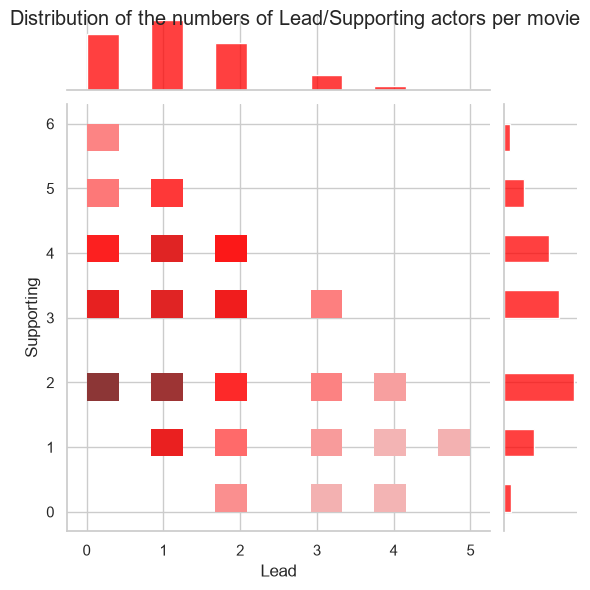

In [55]:
sns.jointplot(cast.groupby(['title_id', 'role_type']).size().unstack(level=1).fillna(0), x='Lead', y='Supporting', kind='hist', color='red')
plt.suptitle('Distribution of the numbers of Lead/Supporting actors per movie')
plt.show()

We see there are no anomalous movies or shows without lead or supporting actors or with just one actor. Otherwise the distributions look pretty reasonable.

In [56]:
cast.groupby(['actor_name', 'role_type']).size().unstack(level=1).fillna(0)

role_type,Lead,Supporting
actor_name,,
Adam Driver,26,63
Aishwarya Rai,21,62
Anya Taylor-Joy,29,65
Awkwafina,20,68
Bae Doona,23,50
Cate Blanchett,17,54
Deepika Padukone,27,61
Denzel Washington,20,53
Emma Stone,19,47


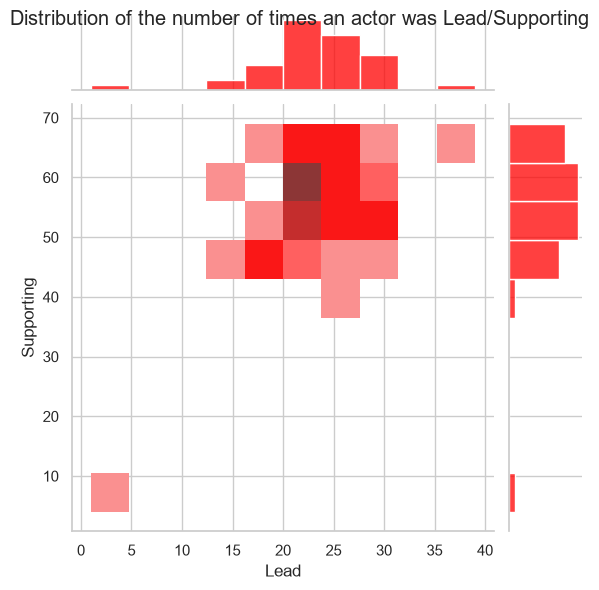

In [57]:
sns.jointplot(cast.groupby(['actor_name', 'role_type']).size().unstack(level=1).fillna(0), x='Lead', y='Supporting', kind='hist', color='red')
plt.suptitle('Distribution of the number of times an actor was Lead/Supporting')
plt.show()

The only outlier here is Unknown - otherwise each actor gets put into both kind of roles pretty often.

### Ratings

In [58]:
# ratings
ratings

,rating_id,title_id,user_id,rating,rating_date
0,1,t0001,u02758,3,2021-06-11
1,2,t0001,u02508,4,2023-10-22
2,3,t0001,u07723,5,2022-09-10
3,4,t0001,u04403,4,2024-05-04
4,5,t0001,u00474,4,2023-09-16
...,...,...,...,...,...
33530,33531,t0143,u03031,5,2022-12-02
33531,33532,t0143,u06453,5,2023-06-22
33532,33533,t0143,u04445,4,2024-06-24
33533,33534,t0143,u01669,5,2024-02-19


In [59]:
ratings.dtypes

rating_id      int64
title_id         str
user_id          str
rating         int64
rating_date      str
dtype: object

In [60]:
ratings['rating_date'] = pd.to_datetime(ratings['rating_date'])
ratings

,rating_id,title_id,user_id,rating,rating_date
0,1,t0001,u02758,3,2021-06-11
1,2,t0001,u02508,4,2023-10-22
2,3,t0001,u07723,5,2022-09-10
3,4,t0001,u04403,4,2024-05-04
4,5,t0001,u00474,4,2023-09-16
...,...,...,...,...,...
33530,33531,t0143,u03031,5,2022-12-02
33531,33532,t0143,u06453,5,2023-06-22
33532,33533,t0143,u04445,4,2024-06-24
33533,33534,t0143,u01669,5,2024-02-19


Once again we see those problematic 16 and 143 in the bottom. As this is the fourth time, we can remove them right away now:

In [61]:
ratings[ratings['title_id'] == 't0016'].index[
    ratings[ratings['title_id'] == 't0016'].index
    < np.mean(ratings[ratings['title_id'] == 't0016'].index)
], ratings[ratings['title_id'] == 't0016'].index[
    ratings[ratings['title_id'] == 't0016'].index
    > np.mean(ratings[ratings['title_id'] == 't0016'].index)
]

(Index([ 840,  841,  842,  843,  844,  845,  846,  847,  848,  849,
        ...
        1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139],
       dtype='int64', length=300),
 Index([33515, 33516, 33517, 33518, 33519], dtype='int64'))

In [62]:
ratings[ratings['title_id'] == 't0143'].index[
    ratings[ratings['title_id'] == 't0143'].index
    < np.mean(ratings[ratings['title_id'] == 't0143'].index)
], ratings[ratings['title_id'] == 't0143'].index[
    ratings[ratings['title_id'] == 't0143'].index
    > np.mean(ratings[ratings['title_id'] == 't0143'].index)
]

(Index([6075, 6076, 6077, 6078, 6079, 6080, 6081, 6082, 6083, 6084, 6085, 6086,
        6087, 6088, 6089],
       dtype='int64'),
 Index([33520, 33521, 33522, 33523, 33524, 33525, 33526, 33527, 33528, 33529,
        33530, 33531, 33532, 33533, 33534],
       dtype='int64'))

In [63]:
ratings = ratings[~((ratings.index > 30000) & (ratings['title_id'].isin(['t0016', 't0143'])))]
ratings

,rating_id,title_id,user_id,rating,rating_date
0,1,t0001,u02758,3,2021-06-11
1,2,t0001,u02508,4,2023-10-22
2,3,t0001,u07723,5,2022-09-10
3,4,t0001,u04403,4,2024-05-04
4,5,t0001,u00474,4,2023-09-16
...,...,...,...,...,...
33510,33511,t0800,u00691,4,2023-01-02
33511,33512,t0800,u04068,3,2022-11-19
33512,33513,t0800,u07819,1,2022-12-18
33513,33514,t0800,u01261,3,2023-03-16


In [64]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 33515 entries, 0 to 33514
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   rating_id    33515 non-null  int64         
 1   title_id     33515 non-null  str           
 2   user_id      33515 non-null  str           
 3   rating       33515 non-null  int64         
 4   rating_date  33515 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 1.3 MB


In [65]:
ratings.isna().any()

rating_id      False
title_id       False
user_id        False
rating         False
rating_date    False
dtype: bool

In [66]:
ratings.duplicated().any(), ratings.duplicated(['title_id', 'user_id']).any()

(np.False_, np.True_)

In [67]:
ratings.groupby(['title_id', 'user_id']).size().sort_values()[ratings.groupby(['title_id', 'user_id']).size().sort_values() >= 2]

title_id  user_id
t0005     u01732     2
          u05674     2
          u06257     2
          u07373     2
t0006     u00313     2
                    ..
t0649     u01832     2
t0483     u02204     2
t0649     u06850     2
          u06922     2
t0438     u05882     3
Length: 294, dtype: int64

In [68]:
ratings[(ratings['user_id'] == 'u05882') & (ratings['title_id'] == 't0438')]

,rating_id,title_id,user_id,rating,rating_date
17749,17750,t0438,u05882,4,2016-07-13
17773,17774,t0438,u05882,3,2017-03-09
17965,17966,t0438,u05882,4,2020-03-20


Apparently one user can rate a title several times, which makes sense. No need to remove such points from the table.

In [69]:
ratings['rating_id'].value_counts().max()

np.int64(1)

In [70]:
set(ratings['title_id']) == set(titles['title_id'])  # each movie has at least one rating

True

In [71]:
ratings['title_id'].value_counts().value_counts()

count
5      239
15     224
40     209
100     89
300     39
Name: count, dtype: int64

The number of ratings per film is distributed in a skewed way, but that's okay and does not contradict anything.

In [72]:
ratings['user_id'].value_counts().value_counts().sort_index()

count
1      474
2     1104
3     1466
4     1545
5     1353
6      887
7      526
8      301
9      141
10      49
11      22
12       4
13       1
16       1
Name: count, dtype: int64

The number of ratings per user also is very skewed, which makes sense - most of the users leave only a couple of reviews, while few do more than 8.

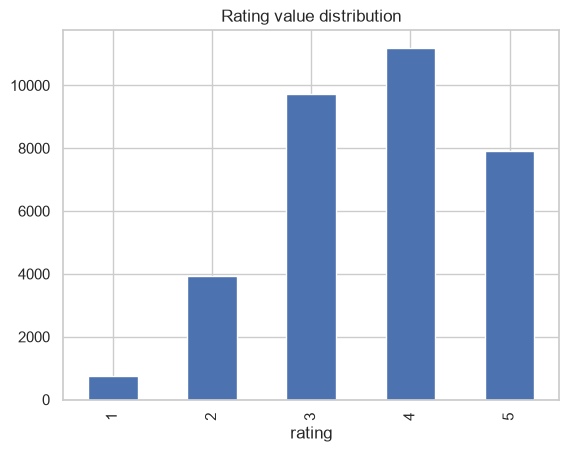

In [73]:
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating value distribution')
plt.show()

Ratings are distributed very unevenly, with much more positive ratings and 4 being the most frequent, and 1 being very infrequent.

In [74]:
ratings['rating_date'].sort_values()  # between 2015 and 2024

31162   2015-01-15
22940   2015-02-09
11285   2015-02-18
9842    2015-03-13
17178   2015-03-14
           ...    
24181   2024-06-30
18982   2024-06-30
19796   2024-06-30
31733   2024-06-30
3513    2024-06-30
Name: rating_date, Length: 33515, dtype: datetime64[us]

In [75]:
m = ratings.merge(titles[['title_id', 'date_added']], on='title_id')
m = m[(m['rating_date'] < m['date_added'])]
m

,rating_id,title_id,user_id,rating,rating_date,date_added
1145,1146,t0018,u05587,4,2022-01-13,2023-06-30
1146,1147,t0018,u02989,4,2022-07-17,2023-06-30
1147,1148,t0018,u05333,4,2022-09-22,2023-06-30
1148,1149,t0018,u07598,4,2021-02-07,2023-06-30
2168,2169,t0049,u02655,5,2020-03-25,2020-06-30
...,...,...,...,...,...,...
31824,31825,t0753,u00346,3,2022-11-21,2023-06-30
31825,31826,t0753,u00994,1,2022-06-08,2023-06-30
31827,31828,t0753,u02850,3,2020-03-16,2023-06-30
31828,31829,t0753,u07341,3,2021-03-13,2023-06-30


As we see here, our method of imputing the missing date_added for titles is not entirely correct - we get entries where the title was rated before being added.

In [76]:
_titles_tmp = pd.read_csv("titles.csv")
_titles_tmp['date_added'] = pd.to_datetime(_titles_tmp['date_added'])
_titles_tmp[_titles_tmp['title_id'].isin(m['title_id'].unique())]

,title_id,type,title,director,country,date_added,release_year,content_rating,duration
17,t0018,Movie,Falling Life,NaN,Egypt,NaT,2023,NR,80 min
48,t0049,Movie,Wild Peace,Pedro Almodóvar,Mexico,NaT,2020,TV-PG,137 min
157,t0158,Movie,Rising Mystery Chronicles,Anurag Kashyap,United Kingdom,NaT,2023,TV-Y7,96 min
189,t0190,Movie,Golden Secret of Time,Wes Anderson,Brazil,NaT,2020,NR,171 min
284,t0285,Movie,Above Shadow,NaN,Egypt,NaT,2023,PG-13,156 min
423,t0424,TV Show,Hidden War of Time,NaN,Spain,NaT,2021,PG-13,3 Seasons
537,t0538,Movie,Modern House,Anurag Kashyap,Mexico,NaT,2022,R,97 min
557,t0558,Movie,Last Mystery: Origins,Céline Sciamma,NaN,NaT,2023,TV-Y7,138 min
643,t0644,TV Show,Modern Song Chronicles,Denis Villeneuve,South Korea,NaT,2023,TV-Y,2 Seasons
659,t0660,Movie,Broken City,NaN,South Korea,NaT,2023,TV-PG,86 min


As we see, all problematic titles really had an empty date_added. That means that our attempt at filling them was wrong, and we should instead fill them with the minimum rating date for all those cases (not for all of the initial NaTs, as what we did was still reasonable - no need to replace it if it does not contradict the ratings).

In [77]:
m = m.groupby('title_id')['rating_date'].min()
m

title_id
t0018   2021-02-07
t0049   2020-01-25
t0158   2020-04-26
t0190   2020-06-17
t0285   2020-02-20
t0424   2020-01-12
t0538   2020-01-01
t0558   2020-02-16
t0644   2020-02-23
t0660   2020-01-19
t0706   2020-01-19
t0749   2020-03-31
t0753   2020-01-16
Name: rating_date, dtype: datetime64[us]

In [78]:
titles = titles.merge(m, how='left', left_on='title_id', right_index=True)
titles['date_added'] = np.where(titles['rating_date'].isna(), titles['date_added'], titles['rating_date'])
titles = titles.drop('rating_date', axis=1)
titles

,title_id,type,title,director,country,date_added,release_year,content_rating,duration,duration_num,duration_unit
0,t0001,Movie,Above War,Guillermo del Toro,Nigeria,2021-04-11,2018,PG,179 min,179,min
1,t0002,Movie,Modern Dream,David Fincher,Canada,2016-01-07,2021,TV-MA,138 min,138,min
2,t0003,Movie,The Life Season,Céline Sciamma,Nigeria,2017-09-17,2010,Unknown,146 min,146,min
3,t0004,Movie,Under Days,Wes Anderson,Nigeria,2022-05-06,1997,PG-13,105 min,105,min
4,t0005,Movie,Lost Kingdom,Unknown,India,2018-04-06,2023,TV-14,119 min,119,min
...,...,...,...,...,...,...,...,...,...,...,...
795,t0796,TV Show,Eternal House,Céline Sciamma,Japan,2021-10-07,1995,G,6 Seasons,6,Seasons
796,t0797,TV Show,Beyond Secret: Reborn,Guillermo del Toro,Japan,2015-01-01,2014,PG-13,9 Seasons,9,Seasons
797,t0798,TV Show,Ancient Sun: Reborn,Unknown,United States,2017-09-24,2010,TV-MA,8 Seasons,8,Seasons
798,t0799,Movie,Golden Water: Origins,Unknown,Japan,2022-12-05,2002,TV-PG,83 min,83,min


In [79]:
titles.isna().sum()

title_id          0
type              0
title             0
director          0
country           0
date_added        0
release_year      0
content_rating    0
duration          0
duration_num      0
duration_unit     0
dtype: int64

In [80]:
m = ratings.merge(titles[['title_id', 'date_added']], on='title_id')
m = m[(m['rating_date'] < m['date_added'])]
m

,rating_id,title_id,user_id,rating,rating_date,date_added


In [81]:
# viewership
viewership

,view_id,title_id,month,views
0,1,t0001,2021-04,2001
1,2,t0001,2021-05,2519
2,3,t0001,2021-06,2154
3,4,t0001,2021-07,1727
4,5,t0001,2021-08,1535
...,...,...,...,...
48638,48639,t0143,2024-02,1098
48639,48640,t0143,2024-03,1020
48640,48641,t0143,2024-04,1333
48641,48642,t0143,2024-05,1669


In [82]:
viewership.tail(100)

,view_id,title_id,month,views
48543,48544,t0016,2019-01,320
48544,48545,t0016,2019-02,284
48545,48546,t0016,2019-03,266
48546,48547,t0016,2019-04,348
48547,48548,t0016,2019-05,210
...,...,...,...,...
48638,48639,t0143,2024-02,1098
48639,48640,t0143,2024-03,1020
48640,48641,t0143,2024-04,1333
48641,48642,t0143,2024-05,1669


Just as before - remove 16 and 143 from the table tail.

In [83]:
viewership[viewership['title_id'] == 't0016'].index[
    viewership[viewership['title_id'] == 't0016'].index
    < np.mean(viewership[viewership['title_id'] == 't0016'].index)
], viewership[viewership['title_id'] == 't0016'].index[
    viewership[viewership['title_id'] == 't0016'].index
    > np.mean(viewership[viewership['title_id'] == 't0016'].index)
]

(Index([ 988,  989,  990,  991,  992,  993,  994,  995,  996,  997,  998,  999,
        1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011,
        1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023,
        1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035,
        1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047,
        1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1056],
       dtype='int64'),
 Index([48540, 48541, 48542, 48543, 48544, 48545, 48546, 48547, 48548, 48549,
        48550, 48551, 48552, 48553, 48554, 48555, 48556, 48557, 48558, 48559,
        48560, 48561, 48562, 48563, 48564, 48565, 48566, 48567, 48568, 48569,
        48570, 48571, 48572, 48573, 48574, 48575, 48576, 48577, 48578, 48579,
        48580, 48581, 48582, 48583, 48584, 48585, 48586, 48587, 48588, 48589,
        48590, 48591, 48592, 48593, 48594, 48595, 48596, 48597, 48598, 48599,
        48600, 48601, 48602, 48603, 48604, 486

In [84]:
viewership[viewership['title_id'] == 't0143'].index[
    viewership[viewership['title_id'] == 't0143'].index
    < np.mean(viewership[viewership['title_id'] == 't0143'].index)
], viewership[viewership['title_id'] == 't0143'].index[
    viewership[viewership['title_id'] == 't0143'].index
    > np.mean(viewership[viewership['title_id'] == 't0143'].index)
]

(Index([8550, 8551, 8552, 8553, 8554, 8555, 8556, 8557, 8558, 8559, 8560, 8561,
        8562, 8563, 8564, 8565, 8566, 8567, 8568, 8569, 8570, 8571, 8572, 8573,
        8574, 8575, 8576, 8577, 8578, 8579, 8580, 8581, 8582, 8583],
       dtype='int64'),
 Index([48609, 48610, 48611, 48612, 48613, 48614, 48615, 48616, 48617, 48618,
        48619, 48620, 48621, 48622, 48623, 48624, 48625, 48626, 48627, 48628,
        48629, 48630, 48631, 48632, 48633, 48634, 48635, 48636, 48637, 48638,
        48639, 48640, 48641, 48642],
       dtype='int64'))

In [85]:
viewership = viewership[~((viewership.index > 40000) & (viewership['title_id'].isin(['t0016', 't0143'])))]
viewership

,view_id,title_id,month,views
0,1,t0001,2021-04,2001
1,2,t0001,2021-05,2519
2,3,t0001,2021-06,2154
3,4,t0001,2021-07,1727
4,5,t0001,2021-08,1535
...,...,...,...,...
48535,48536,t0800,2024-02,1592
48536,48537,t0800,2024-03,1251
48537,48538,t0800,2024-04,1296
48538,48539,t0800,2024-05,1171


In [86]:
viewership.dtypes

view_id     int64
title_id      str
month         str
views       int64
dtype: object

In [87]:
viewership['month'] = pd.to_datetime(viewership['month'])

In [88]:
viewership.info()

<class 'pandas.DataFrame'>
RangeIndex: 48540 entries, 0 to 48539
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   view_id   48540 non-null  int64         
 1   title_id  48540 non-null  str           
 2   month     48540 non-null  datetime64[us]
 3   views     48540 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 1.5 MB


In [89]:
viewership.isna().any()

view_id     False
title_id    False
month       False
views       False
dtype: bool

In [90]:
viewership.duplicated().any(), viewership.duplicated(['title_id', 'month']).any()

(np.False_, np.False_)

In [91]:
viewership['view_id'].value_counts().max()  # ids are unique

np.int64(1)

In [92]:
set(viewership['title_id']) == set(titles['title_id'])  # all titles have viewership

True

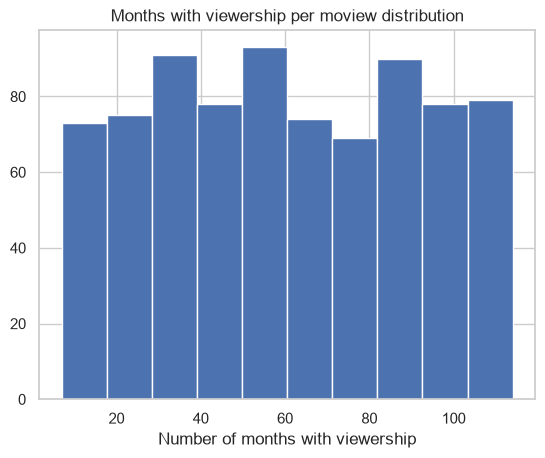

In [93]:
viewership['title_id'].value_counts().plot(kind='hist')
plt.xlabel('Number of months with viewership')
plt.ylabel('')
plt.title('Months with viewership per moview distribution')
plt.show()

In [94]:
viewership['month'].drop_duplicates().dt.year.value_counts().sort_index()

month
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024     6
Name: count, dtype: int64

Gotta also check that all the viewership came after adding the film to the system:

In [95]:
m = titles.merge(viewership.groupby('title_id')['month'].min(), how='left', left_on='title_id', right_index=True)
(m['date_added'].dt.to_period('M') <= m['month'].dt.to_period('M')).all()

np.False_

In [96]:
m = m[m['date_added'].dt.to_period('M') > m['month'].dt.to_period('M')]
m

,title_id,type,title,director,country,date_added,release_year,content_rating,duration,duration_num,duration_unit,month
17,t0018,Movie,Falling Life,Unknown,Egypt,2021-02-07,2023,NR,80 min,80,min,2020-01-01
157,t0158,Movie,Rising Mystery Chronicles,Anurag Kashyap,United Kingdom,2020-04-26,2023,TV-Y7,96 min,96,min,2020-01-01
189,t0190,Movie,Golden Secret of Time,Wes Anderson,Brazil,2020-06-17,2020,NR,171 min,171,min,2020-01-01
284,t0285,Movie,Above Shadow,Unknown,Egypt,2020-02-20,2023,PG-13,156 min,156,min,2020-01-01
557,t0558,Movie,Last Mystery: Origins,Céline Sciamma,Unknown,2020-02-16,2023,TV-Y7,138 min,138,min,2020-01-01
643,t0644,TV Show,Modern Song Chronicles,Denis Villeneuve,South Korea,2020-02-23,2023,TV-Y,2 Seasons,2,Seasons,2020-01-01
748,t0749,Movie,Modern Peace,Anurag Kashyap,France,2020-03-31,2020,TV-PG,81 min,81,min,2020-01-01


In [97]:
_titles_tmp.loc[m.index]

,title_id,type,title,director,country,date_added,release_year,content_rating,duration
17,t0018,Movie,Falling Life,NaN,Egypt,NaT,2023,NR,80 min
157,t0158,Movie,Rising Mystery Chronicles,Anurag Kashyap,United Kingdom,NaT,2023,TV-Y7,96 min
189,t0190,Movie,Golden Secret of Time,Wes Anderson,Brazil,NaT,2020,NR,171 min
284,t0285,Movie,Above Shadow,NaN,Egypt,NaT,2023,PG-13,156 min
557,t0558,Movie,Last Mystery: Origins,Céline Sciamma,NaN,NaT,2023,TV-Y7,138 min
643,t0644,TV Show,Modern Song Chronicles,Denis Villeneuve,South Korea,NaT,2023,TV-Y,2 Seasons
748,t0749,Movie,Modern Peace,Anurag Kashyap,France,NaT,2020,TV-PG,81 min


As with ratings, we just replace those problematic date_added with the new minimum we know - start of the month of the first recorded viewership.

In [98]:
titles = titles.merge(m[['title_id', 'month']], on='title_id', how='left')
titles['date_added'] = np.where(titles['month'].isna(), titles['date_added'], titles['month'])
titles = titles.drop('month', axis=1)
titles

,title_id,type,title,director,country,date_added,release_year,content_rating,duration,duration_num,duration_unit
0,t0001,Movie,Above War,Guillermo del Toro,Nigeria,2021-04-11,2018,PG,179 min,179,min
1,t0002,Movie,Modern Dream,David Fincher,Canada,2016-01-07,2021,TV-MA,138 min,138,min
2,t0003,Movie,The Life Season,Céline Sciamma,Nigeria,2017-09-17,2010,Unknown,146 min,146,min
3,t0004,Movie,Under Days,Wes Anderson,Nigeria,2022-05-06,1997,PG-13,105 min,105,min
4,t0005,Movie,Lost Kingdom,Unknown,India,2018-04-06,2023,TV-14,119 min,119,min
...,...,...,...,...,...,...,...,...,...,...,...
795,t0796,TV Show,Eternal House,Céline Sciamma,Japan,2021-10-07,1995,G,6 Seasons,6,Seasons
796,t0797,TV Show,Beyond Secret: Reborn,Guillermo del Toro,Japan,2015-01-01,2014,PG-13,9 Seasons,9,Seasons
797,t0798,TV Show,Ancient Sun: Reborn,Unknown,United States,2017-09-24,2010,TV-MA,8 Seasons,8,Seasons
798,t0799,Movie,Golden Water: Origins,Unknown,Japan,2022-12-05,2002,TV-PG,83 min,83,min


In [99]:
titles.isna().any().any()

np.False_

In [100]:
m = titles.merge(viewership.groupby('title_id')['month'].min(), how='left', left_on='title_id', right_index=True)
(m['date_added'].dt.to_period('M') <= m['month'].dt.to_period('M')).all()

np.True_

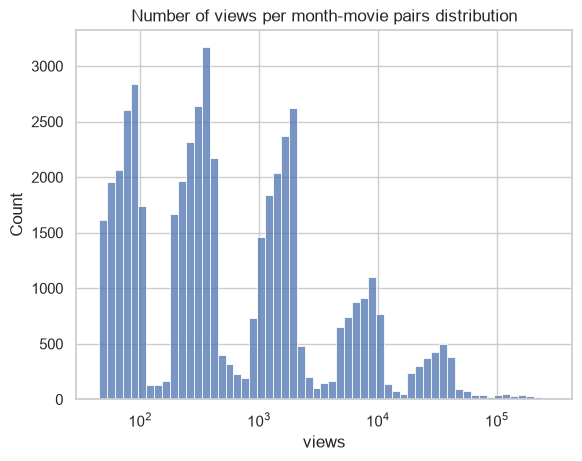

In [101]:
sns.histplot(viewership['views'], log_scale=True)
plt.title('Number of views per month-movie pairs distribution')
plt.show()

We see that distribution of views for each film per month has different scales with several peaks in terms of logarithmic distribution. This is normal for such a metric - there are very viral movies and there are some very obscure ones.

## 4. Analysis

Answer each question with code + chart + a written finding.

### 📊 Section A — Catalog Overview

#### Q1 — Number of titles, Movie vs TV Show split

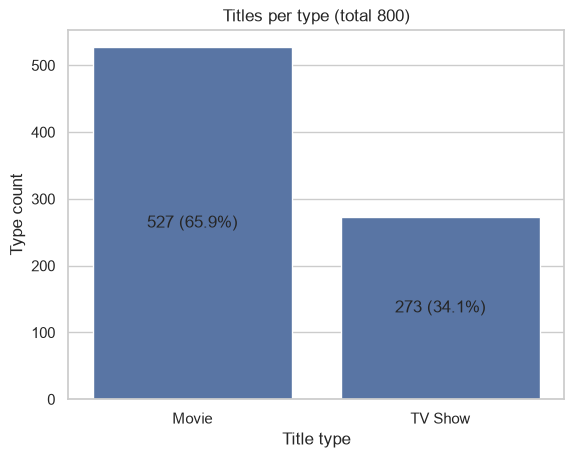

In [102]:
# Your code here
sns.countplot(titles, x='type')
for type_, gr in titles.groupby('type'):
    plt.text(type_, len(gr)/2, f'{len(gr)} ({len(gr)/len(titles):.1%})', ha='center', va='center')
plt.title(f'Titles per type (total {len(titles)})')
plt.xlabel('Title type')
plt.ylabel('Type count')
plt.savefig(
    "pictures/q1.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)
plt.show()

**Findings:** We have twice as much Movies as TV Shows. Total titles is 800.

#### Q2 — Catalog growth by year (`date_added`)

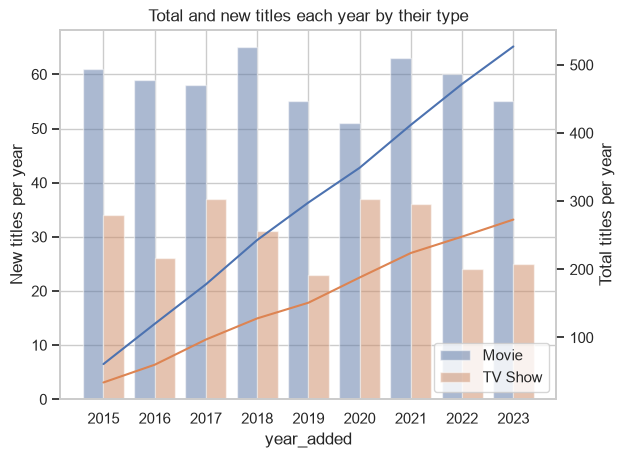

In [122]:
# Your code here
# Your code here
cur_df = titles.copy()
cur_df['year_added'] = cur_df['date_added'].dt.year
cur_df = cur_df.groupby(['type', 'year_added'], as_index=False).agg(n_new_titles=('title_id', 'nunique'))
cur_df['n_total_titles'] = cur_df.sort_values('year_added').groupby('type')['n_new_titles'].cumsum()

sns.barplot(cur_df, x='year_added', y='n_new_titles', hue='type', alpha=0.5)
plt.legend(loc='lower right')
plt.grid(True)
plt.ylabel('New titles per year')

ax = plt.twinx()
for type_, gr in cur_df.groupby('type'):
    ax.plot(gr['year_added'].astype(str), gr['n_total_titles'])
plt.grid(False)
plt.ylabel('Total titles per year')

plt.title('Total and new titles each year by their type')
plt.savefig(
    "pictures/q2.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)
plt.show()


**Findings:** We see that the rate of titles being added to the site stays roughly uniform over the years. Also the fractions of Movies and Shows stays close to 2/1 over the entire history. The notable year here is 2020, where there are noticably more Shows than normal when compared to Movies, almost 80% of the number of Movies. It probably happened because of COVID and users having more demand for longer-form content, and it also falls right after the ending of Game of Thrones as the biggest TV Show at the time, which brought in more investors into making Shows instead of Movies.

#### Q3 — Most common content ratings

In [ ]:
# Your code here
rating_df = titles.groupby('content_rating').agg(n_titles=('title_id', 'nunique')).sort_values('n_titles', ascending=False)

rating_type_df = titles.groupby(['type', 'content_rating']).agg(n_titles=('title_id', 'nunique')).unstack(level=0).fillna(0)
rating_type_df = rating_type_df.loc[rating_df.index].stack().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(rating_type_df, x='content_rating', y='n_titles', hue='type')
plt.xlabel('Content rating')
plt.ylabel('Number of titles')
plt.title('Number of titles per type and content rating')
plt.savefig(
    "pictures/q3_1.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)
plt.show()

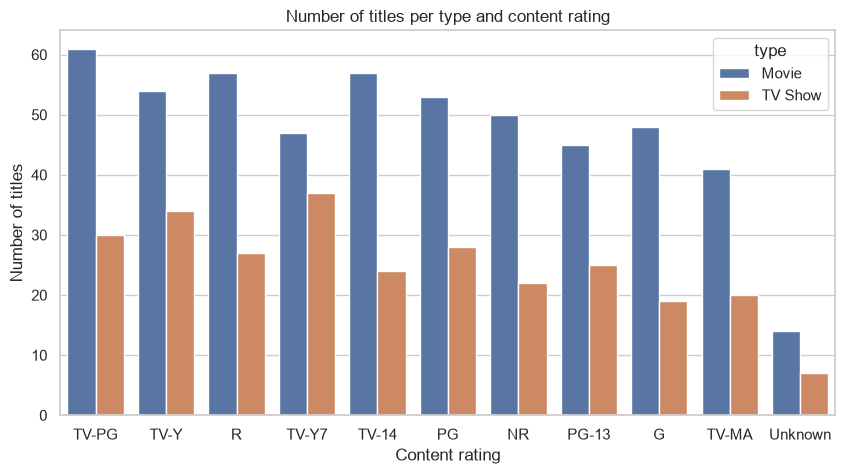

**Findings:** The most common ratings are TV ones, with TV-PG being the most frequent. Among non-TV rating the most frequent is R, which is default for many action movies or shows. The fraction of Movies to Shows in each rating is once again very close to 2/1, with the notable exception being TV-Y7, which has a bigger share of Shows. TV-Y7 is older children above 7 years old, so it would make sense that this content rating group would contain a lot of cartoons, which are most often Shows rather than Movies.

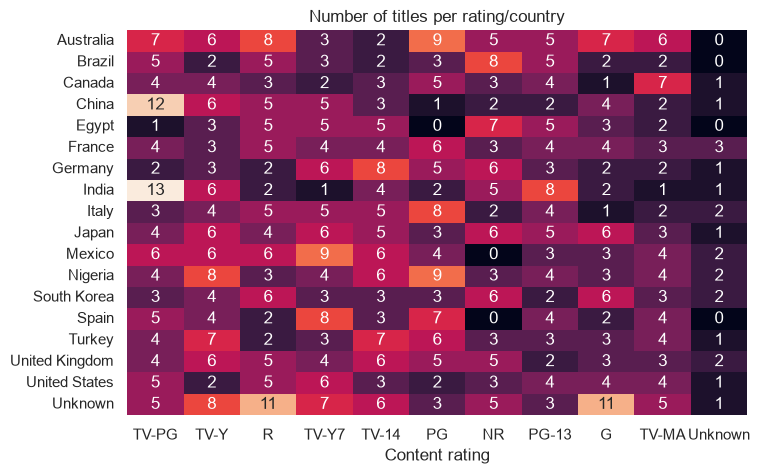

In [161]:
# Your code here
rating_df = titles.groupby('content_rating').agg(n_titles=('title_id', 'nunique')).sort_values('n_titles', ascending=False)

rating_country_df = titles.groupby(['country', 'content_rating']).agg(n_titles=('title_id', 'nunique'))['n_titles'].unstack(level=0).fillna(0)
rating_country_df = rating_country_df.loc[rating_df.index]

plt.figure(figsize=(8, 5))
sns.heatmap(rating_country_df.T, annot=True, cbar=False)
plt.ylabel('')
plt.xlabel('Content rating')
plt.xticks(rotation=0)
plt.title('Number of titles per rating/country')
plt.savefig(
    "pictures/q3_2.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)
plt.show()

**Findings:** We see that the individual country-rating pairs have too few titles to have any noticable pattern. There are some per-country patterns, like e.g. South Korea noticably preferring non-TV ratings like R/NR/G, or India preferring TV-PG over PG. TV-MA, which is supposed to be a more rare alternative to R, is only common in Australia and Canada. Another intereseting thing is that many titles without country are either R or G, G here being the most default content rating (General), and R being the most common non-TV one.

#### Q4 — Top 10 producing countries

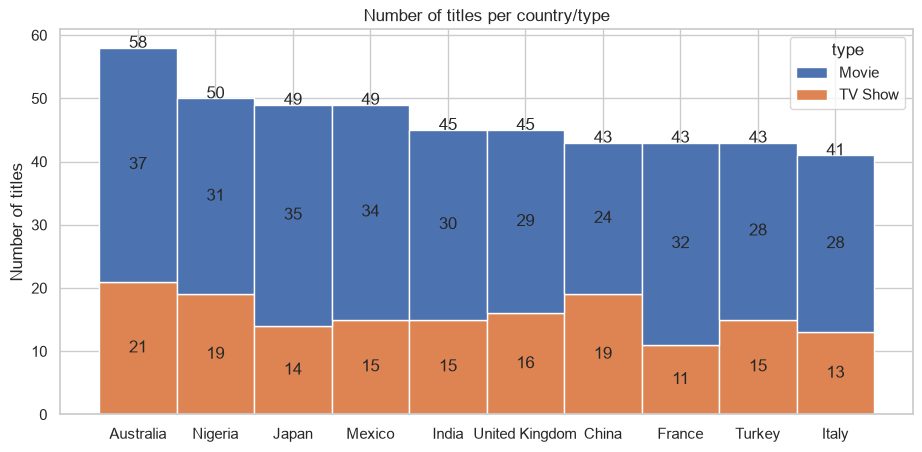

In [ ]:
# Your code here
cur_df = titles.query('country != "Unknown"').groupby(['type', 'country'], as_index=False).agg(n_titles=('title_id', 'nunique'))
# sort the grouping by country's total number of titles
country_sorting = list(cur_df.groupby('country')['n_titles'].sum().sort_values(ascending=False).index)[:10]
cur_df = cur_df[cur_df['country'].isin(country_sorting)].sort_values(
    'country',
    key=lambda s: [country_sorting.index(x) for x in s]
)

plt.figure(figsize=(11, 5))
sns.histplot(cur_df, x='country', weights='n_titles', hue='type', multiple='stack', alpha=1)

for country, gr in cur_df.groupby('country'):
    plt.text(
        country,
        gr['n_titles'].sum(),
        f'{gr['n_titles'].sum()}',
        ha='center'
    )
    plt.text(
        country,
        gr.loc[gr['type'] == 'TV Show', 'n_titles'].sum()/2,
        f'{gr.loc[gr['type'] == 'TV Show', 'n_titles'].sum()}',
        ha='center',
        va='center'
    )
    plt.text(
        country,
        gr.loc[gr['type'] == 'TV Show', 'n_titles'].sum() + gr.loc[gr['type'] == 'Movie', 'n_titles'].sum()/2,
        f'{gr.loc[gr['type'] == 'Movie', 'n_titles'].sum()}',
        ha='center',
        va='center'
    )

plt.ylabel('Number of titles')
plt.xlabel('')
plt.title('Number of titles per country/type')
plt.savefig(
    "pictures/q4.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)
plt.show()

**Findings:** The top-10 countries is very interesting because it is somewhat unexpected. While there are several countries here with well-known movie/show industry, like Mexico, Japan, India, China, and Italy, the US is noticably absent from the top-10. Also Australia by quite a few titles is unexpected. Interesting findings here are that China produces relatively more Shows than other country, and Japan and France relatively less. On average though the proportion between Movies and Shows is maintained here, and few countries stray far from it. One thing we can safely take away from this experiment is that there isn't a very sharp top of most-producing countries - the difference between number 2 and number 10 is just 9 titles.

### 🎭 Section B — Genres & Cast

#### Q5 — Top 10 most common genres

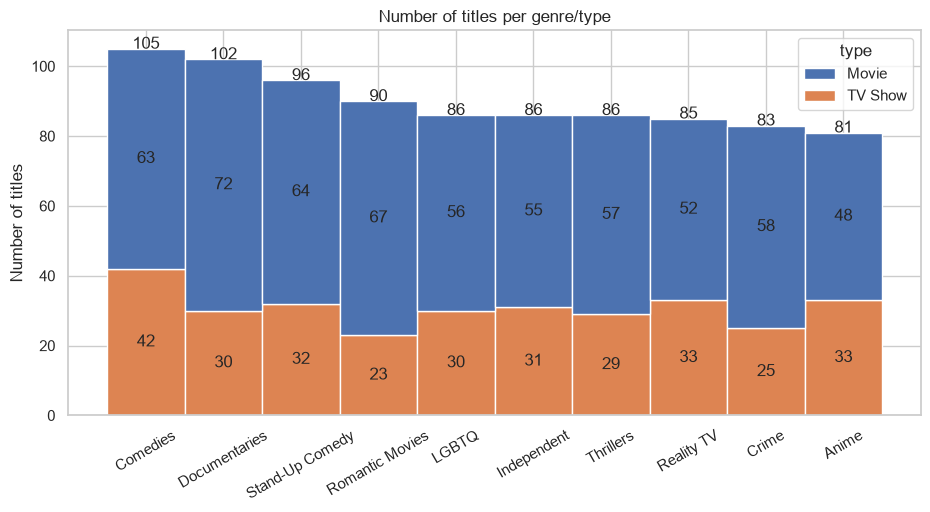

In [ ]:
# Your code here
# we earlier checked that all titles have at least one genre, so we can safely do inner-join
cur_df = pd.merge(titles, genres, on='title_id', how='inner')\
    .groupby(['type', 'genre'], as_index=False).agg(n_titles=('title_id', 'nunique'))  # one row => one unique (title, genre) pair
# sort the grouping by genre's total number of titles
genre_sorting = list(cur_df.groupby('genre')['n_titles'].sum().sort_values(ascending=False).index)[:10]
cur_df = cur_df[cur_df['genre'].isin(genre_sorting)].sort_values(
    'genre',
    key=lambda s: [genre_sorting.index(x) for x in s]
)

plt.figure(figsize=(11, 5))
sns.histplot(cur_df, x='genre', weights='n_titles', hue='type', multiple='stack', alpha=1)

for genre, gr in cur_df.groupby('genre'):
    plt.text(
        genre,
        gr['n_titles'].sum(),
        f'{gr['n_titles'].sum()}',
        ha='center'
    )
    plt.text(
        genre,
        gr.loc[gr['type'] == 'TV Show', 'n_titles'].sum()/2,
        f'{gr.loc[gr['type'] == 'TV Show', 'n_titles'].sum()}',
        ha='center',
        va='center'
    )
    plt.text(
        genre,
        gr.loc[gr['type'] == 'TV Show', 'n_titles'].sum() + gr.loc[gr['type'] == 'Movie', 'n_titles'].sum()/2,
        f'{gr.loc[gr['type'] == 'Movie', 'n_titles'].sum()}',
        ha='center',
        va='center'
    )

plt.ylabel('Number of titles')
plt.xlabel('')
plt.xticks(rotation=30)
plt.title('Number of titles per genre/type')
plt.savefig(
    "pictures/q5.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)
plt.show()

**Findings:** The genres at the very top are mostly lightweight content such as comedy or romance, with one outlier being Documentaries at number 2. Once again, just like with countries, there isn't really a sharp top, with differnce between top-1 and top-10 being just 20%. The shares of Movies and Shows here are still roughly 2 to 1, with notable exceptions in this top-10 being Documentaries, and Romantic _Movies_ having a bigger Movie share, and Comedies, Reality TV and Anime having a bigger TV Show share - all of those are pretty logical considering the nature of those genres.

#### Q6 — Genres by type (Movie vs TV Show)

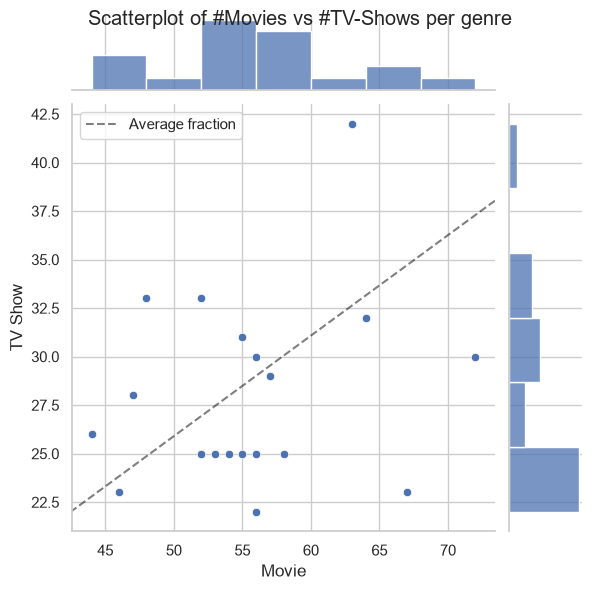

In [228]:
# Your code here
cur_df = pd.merge(titles, genres, on='title_id', how='inner')\
    .groupby(['type', 'genre']).agg(n_titles=('title_id', 'nunique'))['n_titles'].unstack(level=0)
sns.jointplot(cur_df, x='Movie', y='TV Show')
# draw the average fraction of Movies/TV Shows
average_frac = (titles['type'] == 'TV Show').sum() / (titles['type'] == 'Movie').sum()
plt.autoscale(False)
plt.plot(
    np.arange(100), np.arange(100) * average_frac,
    color='black', linestyle='--', alpha=0.5, label='Average fraction'
)
plt.legend()
plt.suptitle('Scatterplot of #Movies vs #TV-Shows per genre')
plt.savefig(
    "pictures/q6.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)
plt.show()

Lets look at the genres with the number of TV Shows differing more than by 5 from the average line:

In [233]:
cur_df[cur_df['TV Show'] > cur_df['Movie'] * average_frac + 5]

type,Movie,TV Show
genre,,
Anime,48,33
Comedies,63,42
Reality TV,52,33


In [234]:
cur_df[cur_df['TV Show'] < cur_df['Movie'] * average_frac - 5]

type,Movie,TV Show
genre,,
Crime,58,25
Documentaries,72,30
Music & Musicals,56,22
Romantic Movies,67,23


**Findings:** The genres with greater than average share of TV Shows are Anime (which are know for be series-based), Comedies (which probably means sitcom - also very common to be a series), and Reality TV (does not make very much sense as a movie). The genres with lower than average share of TV Shows are Crime (pretty common theme for action movies), Documentaries (while there are well-known documentary series, it is still more common to see them as movies), Musicals (very uncommon to be series-based), and Romantic Movies (Movies is literally in the genre name). Apart from those easily explainable outliers, most of the genres fall close to the average relative shares of Movies and TV Shows.

#### Q7 — Top 10 most frequent actors

In [ ]:
# Your code here


**Findings:** 

#### Q8 — Lead vs Supporting actor frequency

In [ ]:
# Your code here


**Findings:** 

### ⭐ Section C — Ratings Analysis

#### Q9 — Overall average rating across all titles

In [ ]:
# Your code here


**Findings:** 

#### Q10 — Top 10 highest-rated titles (min 20 ratings)

In [ ]:
# Your code here


**Findings:** 

#### Q11 — Average rating per genre

In [ ]:
# Your code here


**Findings:** 

#### Q12 — Do Movies or TV Shows get higher ratings?

In [ ]:
# Your code here


**Findings:** 

#### Q13 — Release year vs average rating

In [ ]:
# Your code here


**Findings:** 

### 📈 Section D — Viewership Analysis

#### Q14 — Top 10 most-viewed titles

In [ ]:
# Your code here


**Findings:** 

#### Q15 — Total views per genre

In [ ]:
# Your code here


**Findings:** 

#### Q16 — Monthly viewership trend across the platform

In [ ]:
# Your code here


**Findings:** 

#### Q17 — Are highly-rated titles the most viewed? (correlation)

In [ ]:
# Your code here


**Findings:** 

## 5. 🎯 Final Recommendations

Based on your analysis, provide **3 concrete, data-backed recommendations** for Netflix's content team.

Each recommendation should:
- Reference specific findings above
- Be actionable (not vague)
- Include the *why*

**1.** _(recommendation + reasoning + which questions support it)_

**2.** _(recommendation + reasoning + which questions support it)_

**3.** _(recommendation + reasoning + which questions support it)_